# Q3. Feature Engineering and Regression Pipeline
**Name:** Harish Sukhija  
**Task:** Build a reproducible scikit-learn regression pipeline to predict `items_sold` at a retail store.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# 1. Data Loading & Feature Engineering
try:
    df = pd.read_csv('q3_retail_promotions.csv')
except FileNotFoundError:
    df = pd.read_csv('../data/q3_retail_promotions.csv')

# Convert transaction_date to datetime object
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract year, month, day_of_week
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Create is_month_end (1 if day >= 25, else 0)
df['is_month_end'] = df['transaction_date'].dt.day.apply(lambda x: 1 if x >= 25 else 0)

print("Data after Date Feature Engineering (First 5 rows):")
display(df.head())

Data after Date Feature Engineering (First 5 rows):


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


### Temporal Train-Test Split Explanation
For time-ordered data, **a random split is inappropriate** because it leads to "data leakage." If we split randomly, the model might learn from future events to predict past events, which is impossible in the real world. By sorting chronologically and splitting sequentially (e.g., first 80% of dates for training, last 20% for testing), we accurately simulate how the model will be used in reality: learning from the past to predict the unseen future.

In [2]:
# 2. Temporal Train-Test Split
# Sort data chronologically
df = df.sort_values(by='transaction_date').reset_index(drop=True)

# Calculate the split index
split_idx = int(len(df) * 0.8)

# We drop 'transaction_date' and 'store_id' as they are not predictive features for this pipeline
# (Dates are captured in year/month/day, and store_id would require massive encoding not asked here)
X = df.drop(columns=['items_sold', 'transaction_date', 'store_id'])
y = df['items_sold']

# Sequential Split (No random_state, no shuffle)
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (960, 10)
Test set size: (240, 10)


In [3]:
# 3. Preprocessing Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define columns
categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = ['is_weekend', 'is_festival', 'competition_density',
                  'year', 'month', 'day_of_week', 'is_month_end']

# Create preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

print("Pipeline Preprocessor Ready.")

Pipeline Preprocessor Ready.


Training Models...

--- Linear Regression ---
RMSE: 27.13
MAE: 21.07

--- Random Forest Regressor ---
RMSE: 31.12
MAE: 25.00


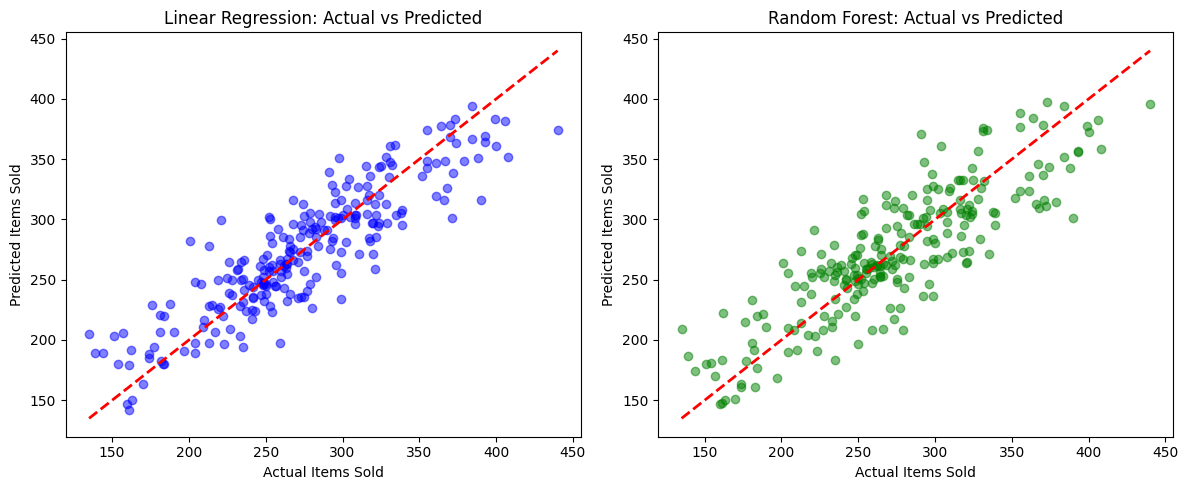

In [4]:
# 4. Model Training and Evaluation
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Build full pipelines
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())])
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(random_state=42))])

# Train models
print("Training Models...")
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# Predict
lr_preds = lr_pipeline.predict(X_test)
rf_preds = rf_pipeline.predict(X_test)

# Evaluation Metrics
print("\n--- Linear Regression ---")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lr_preds)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, lr_preds):.2f}")

print("\n--- Random Forest Regressor ---")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_preds)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, rf_preds):.2f}")

# Parity Plots
plt.figure(figsize=(12, 5))

# Linear Regression Parity Plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, lr_preds, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Items Sold')
plt.ylabel('Predicted Items Sold')
plt.title('Linear Regression: Actual vs Predicted')

# Random Forest Parity Plot
plt.subplot(1, 2, 2)
plt.scatter(y_test, rf_preds, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Items Sold')
plt.ylabel('Predicted Items Sold')
plt.title('Random Forest: Actual vs Predicted')

plt.tight_layout()
plt.show()

In [5]:
# Extract Feature Importances from Random Forest
rf_model = rf_pipeline.named_steps['regressor']
# Get feature names from the OneHotEncoder inside the ColumnTransformer
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = np.concatenate([numerical_cols, cat_feature_names])

importances = rf_model.feature_importances_
importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top 5 Most Influential Features (Random Forest):")
display(importance_df.head(5))

Top 5 Most Influential Features (Random Forest):


,Feature,Importance
1,is_festival,0.173557
17,store_size_small,0.168355
14,location_type_urban,0.108331
5,day_of_week,0.095854
2,competition_density,0.063912
